In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

print("Setup complete")

Setup complete


In [3]:
fraud_df = pd.read_csv("../data/raw/Fraud_Data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [4]:
print("Fraud data shape:", fraud_df.shape)
print("IP data shape:", ip_df.shape)

Fraud data shape: (151112, 11)
IP data shape: (138846, 3)


In [5]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


In [6]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [7]:
fraud_df.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [8]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [9]:
(fraud_df.isnull().sum() / len(fraud_df)) * 100

user_id           0.0
signup_time       0.0
purchase_time     0.0
purchase_value    0.0
device_id         0.0
source            0.0
browser           0.0
sex               0.0
age               0.0
ip_address        0.0
class             0.0
dtype: float64

In [10]:
fraud_df.duplicated().sum()

np.int64(0)

In [11]:
fraud_df = fraud_df.drop_duplicates()

In [12]:
fraud_df.duplicated().sum()

np.int64(0)

In [13]:
fraud_df.dtypes

user_id             int64
signup_time           str
purchase_time         str
purchase_value      int64
device_id             str
source                str
browser               str
sex                   str
age                 int64
ip_address        float64
class               int64
dtype: object

In [14]:
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

In [15]:
fraud_df[['signup_time','purchase_time']].dtypes

signup_time      datetime64[us]
purchase_time    datetime64[us]
dtype: object

In [16]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [17]:
fraud_df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

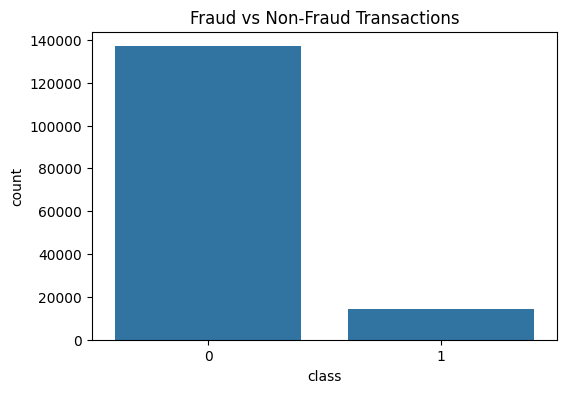

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=fraud_df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()

In [19]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [20]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [21]:
fraud_df.duplicated().sum()

np.int64(0)

In [22]:
fraud_df['class'].value_counts()

class
0    136961
1     14151
Name: count, dtype: int64

In [23]:
fraud_df['class'].value_counts(normalize=True) * 100

class
0    90.635423
1     9.364577
Name: proportion, dtype: float64

In [24]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [25]:
fraud_df.duplicated().sum()

np.int64(0)

In [26]:
fraud_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype         
---  ------          --------------   -----         
 0   user_id         151112 non-null  int64         
 1   signup_time     151112 non-null  datetime64[us]
 2   purchase_time   151112 non-null  datetime64[us]
 3   purchase_value  151112 non-null  int64         
 4   device_id       151112 non-null  str           
 5   source          151112 non-null  str           
 6   browser         151112 non-null  str           
 7   sex             151112 non-null  str           
 8   age             151112 non-null  int64         
 9   ip_address      151112 non-null  float64       
 10  class           151112 non-null  int64         
dtypes: datetime64[us](2), float64(1), int64(4), str(4)
memory usage: 12.7 MB


In [27]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [28]:
fraud_df.duplicated().sum()

np.int64(0)

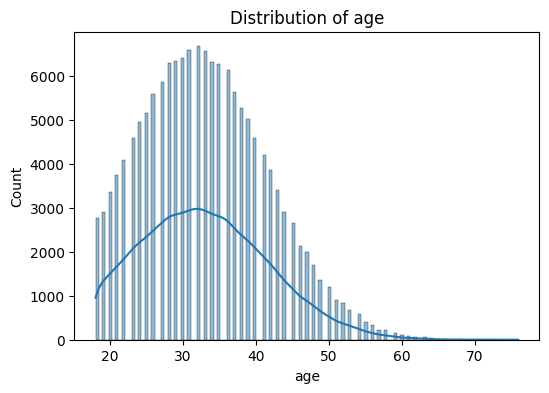

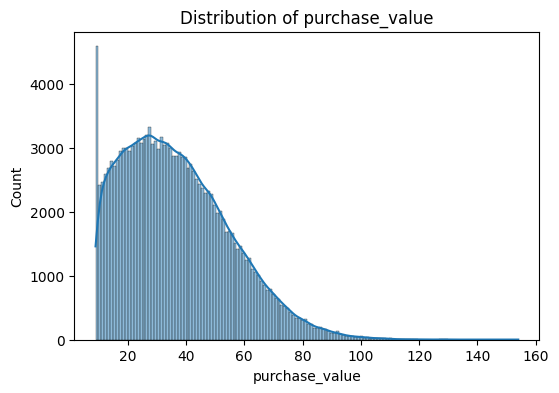

In [29]:
num_cols = ['age', 'purchase_value']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(fraud_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

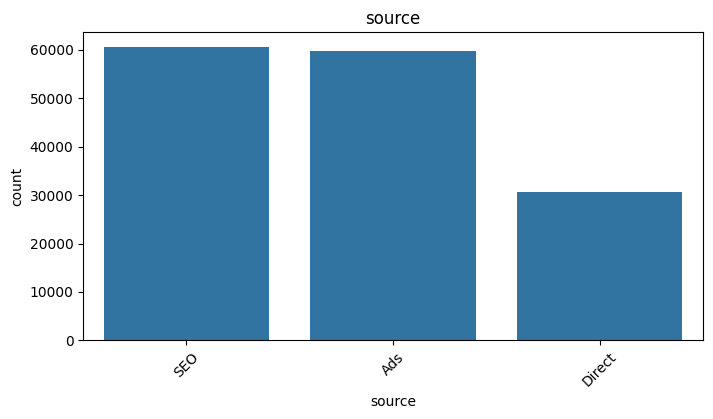

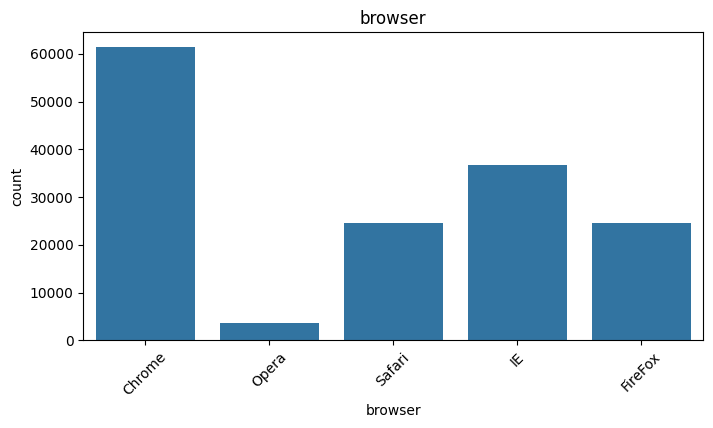

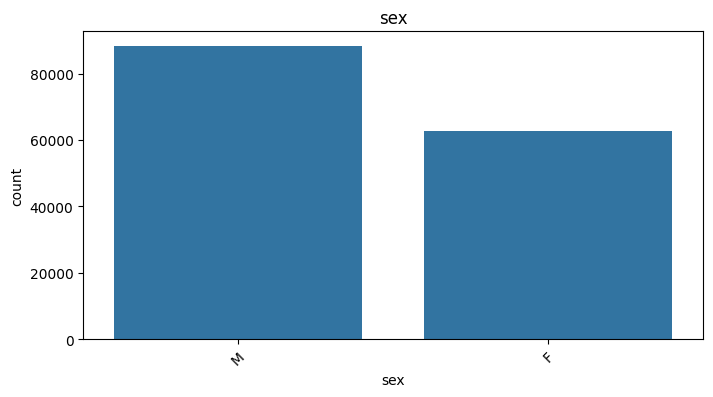

In [30]:
cat_cols = ['source', 'browser', 'sex']

for col in cat_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=fraud_df, x=col)
    plt.title(col)
    plt.xticks(rotation=45)
    plt.show()

In [31]:
fraud_df['age'].describe()

count    151112.000000
mean         33.140704
std           8.617733
min          18.000000
25%          27.000000
50%          33.000000
75%          39.000000
max          76.000000
Name: age, dtype: float64

In [32]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [33]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [34]:
fraud_df.isnull().sum()

user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64

In [35]:
fraud_df.duplicated().sum()

np.int64(0)

In [36]:
fraud_df[['age', 'purchase_value']].describe()

,age,purchase_value
count,151112.000000,151112.000000
mean,33.140704,36.935372
std,8.617733,18.322762
min,18.000000,9.000000
25%,27.000000,22.000000
50%,33.000000,35.000000
75%,39.000000,49.000000
max,76.000000,154.000000


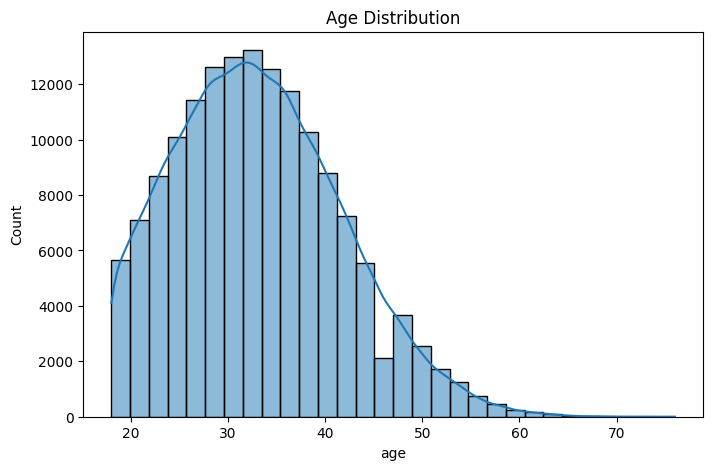

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['age'], bins=30, kde=True)
plt.title('Age Distribution')
plt.show()

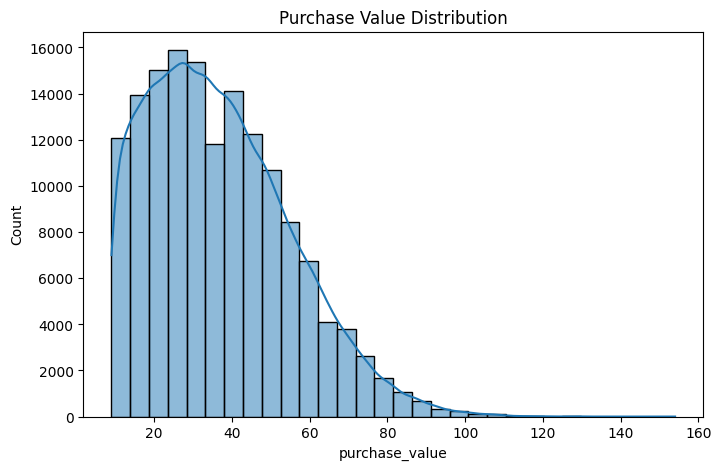

In [38]:
plt.figure(figsize=(8,5))
sns.histplot(fraud_df['purchase_value'], bins=30, kde=True)
plt.title('Purchase Value Distribution')
plt.show()

In [39]:
fraud_df['source'].value_counts()

source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64

In [40]:
fraud_df['browser'].value_counts()

browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64

In [41]:
fraud_df['sex'].value_counts()

sex
M    88293
F    62819
Name: count, dtype: int64

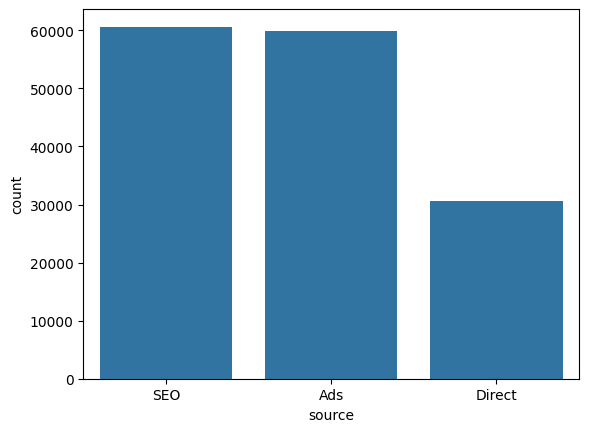

In [42]:
sns.countplot(data=fraud_df, x='source')
plt.show()

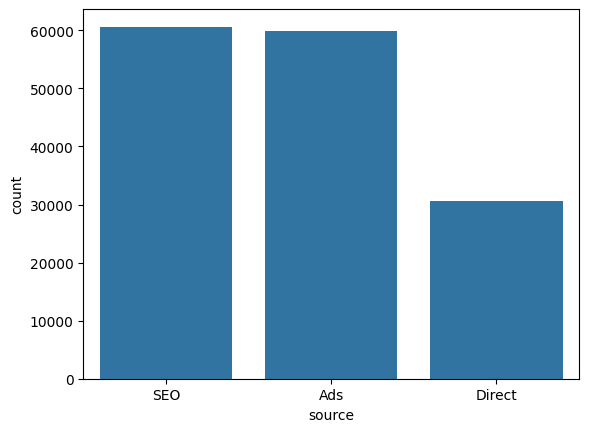

In [43]:
sns.countplot(data=fraud_df, x='source')
plt.show()

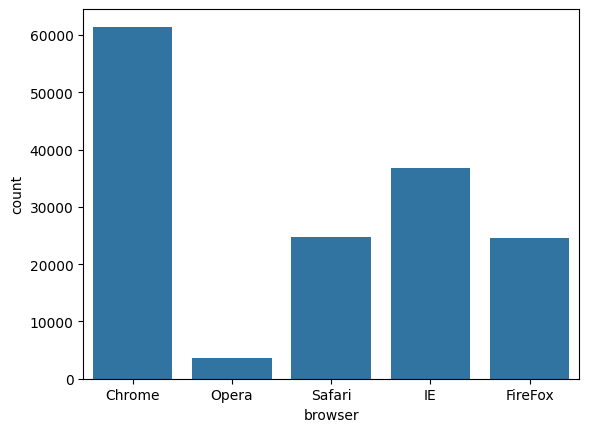

In [44]:
sns.countplot(data=fraud_df, x='browser')
plt.show()

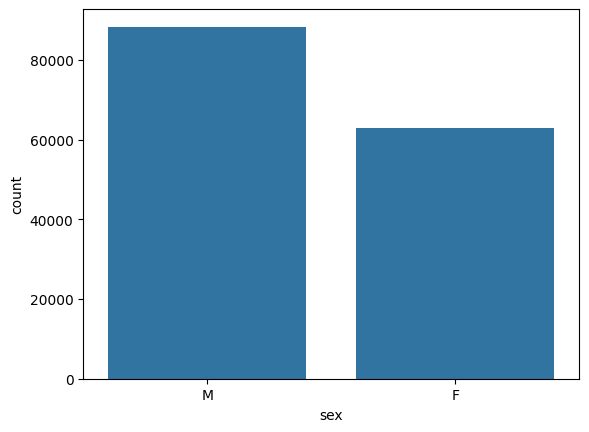

In [45]:
sns.countplot(data=fraud_df, x='sex')
plt.show()

In [46]:
pd.crosstab(fraud_df['sex'], fraud_df['class'])

class,0,1
sex,,
F,57102,5717
M,79859,8434


In [47]:
pd.crosstab(
    fraud_df['sex'],
    fraud_df['class'],
    normalize='index'
) * 100

class,0,1
sex,,
F,90.899250,9.100750
M,90.447714,9.552286


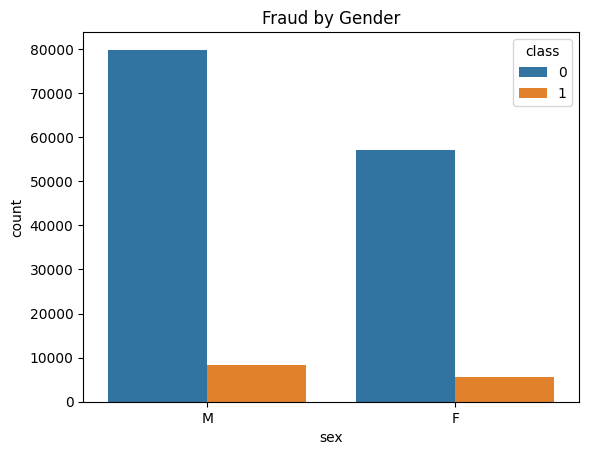

In [48]:
sns.countplot(data=fraud_df, x='sex', hue='class')
plt.title('Fraud by Gender')
plt.show()

In [49]:
pd.crosstab(fraud_df['source'], fraud_df['class'])

class,0,1
source,,
Ads,54368,5513
Direct,27390,3226
SEO,55203,5412


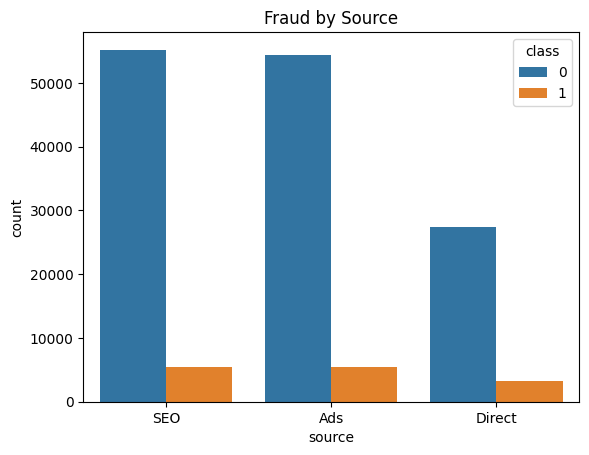

In [50]:
sns.countplot(data=fraud_df, x='source', hue='class')
plt.title('Fraud by Source')
plt.show()

In [52]:
pd.crosstab(fraud_df['browser'], fraud_df['class'])

class,0,1
browser,,
Chrome,55363,6069
FireFox,22268,2342
IE,33540,3187
Opera,3348,328
Safari,22442,2225


In [53]:
pd.crosstab(
    fraud_df['sex'],
    fraud_df['class'],
    normalize='index'
) * 100

class,0,1
sex,,
F,90.899250,9.100750
M,90.447714,9.552286


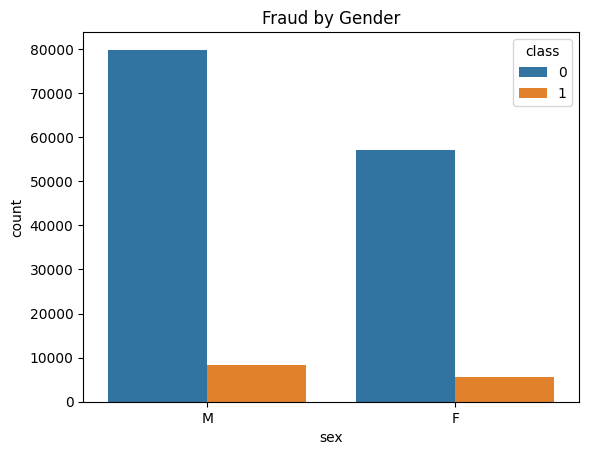

In [54]:
sns.countplot(data=fraud_df, x='sex', hue='class')
plt.title('Fraud by Gender')
plt.show()

In [55]:
pd.crosstab(fraud_df['browser'], fraud_df['class'])

class,0,1
browser,,
Chrome,55363,6069
FireFox,22268,2342
IE,33540,3187
Opera,3348,328
Safari,22442,2225


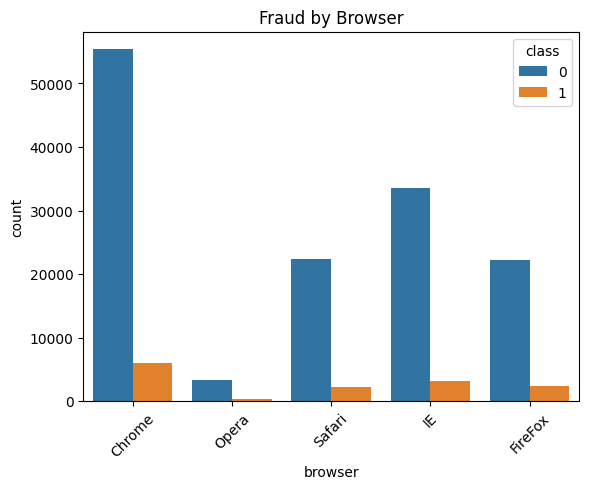

In [56]:
sns.countplot(data=fraud_df, x='browser', hue='class')
plt.xticks(rotation=45)
plt.title('Fraud by Browser')
plt.show()

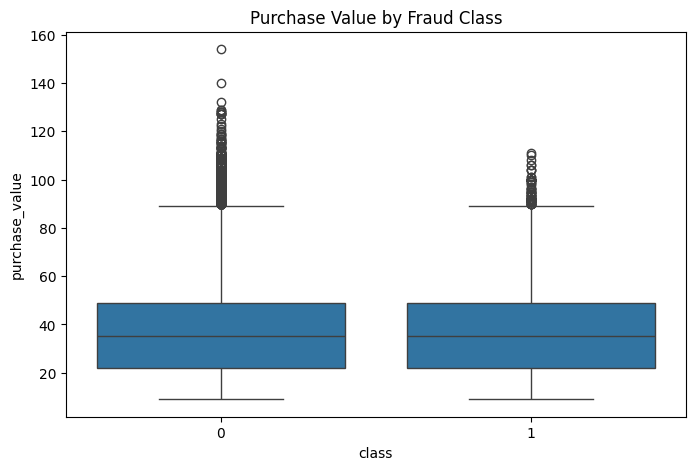

In [57]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=fraud_df,
    x='class',
    y='purchase_value'
)
plt.title('Purchase Value by Fraud Class')
plt.show()

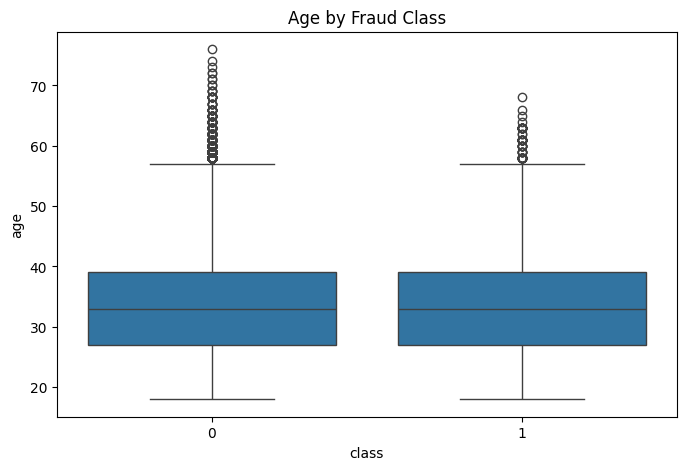

In [58]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=fraud_df,
    x='class',
    y='age'
)
plt.title('Age by Fraud Class')
plt.show()